<a href="https://colab.research.google.com/github/sheylaxiomaramo/Challenge-Alura-Store/blob/main/AluraStoreLatam_Sheyla_Mallco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Sales Analytics

Autor: Sheyla Xiomara Mallco Oré

Proyecto de análisis de datos orientado a comparar el desempeño comercial de cuatro tiendas mediante indicadores de facturación, satisfacción del cliente, categorías vendidas y costos de envío.

El objetivo es identificar patrones comerciales y generar recomendaciones estratégicas basadas en datos.

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importación y comprensión de datos

En esta sección se cargan los datasets correspondientes a las tiendas y se realiza una revisión inicial de la estructura de los datos.

In [134]:
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


## KPIs Principales

In [135]:
# =========================
# KPIs PRINCIPALES
# =========================

# Ventas totales generales
total_ventas = (
    tienda['Precio'].sum() +
    tienda2['Precio'].sum() +
    tienda3['Precio'].sum() +
    tienda4['Precio'].sum()
)

# Ventas por tienda
ventas_tienda = {
    'Tienda 1': tienda['Precio'].sum(),
    'Tienda 2': tienda2['Precio'].sum(),
    'Tienda 3': tienda3['Precio'].sum(),
    'Tienda 4': tienda4['Precio'].sum()
}

# Tienda con mayor ingreso
tienda_top = max(ventas_tienda, key=ventas_tienda.get)

# Calificaciones promedio
calificaciones = {
    'Tienda 1': tienda['Calificación'].mean(),
    'Tienda 2': tienda2['Calificación'].mean(),
    'Tienda 3': tienda3['Calificación'].mean(),
    'Tienda 4': tienda4['Calificación'].mean()
}

# Mejor tienda según calificación
mejor_tienda = max(calificaciones, key=calificaciones.get)

# Costos de envío promedio
envios = {
    'Tienda 1': tienda['Costo de envío'].mean(),
    'Tienda 2': tienda2['Costo de envío'].mean(),
    'Tienda 3': tienda3['Costo de envío'].mean(),
    'Tienda 4': tienda4['Costo de envío'].mean()
}

# Tienda con menor costo de envío
menor_envio = min(envios, key=envios.get)

# =========================
# IMPRESIÓN DE KPIs
# =========================

print("===== KPIs PRINCIPALES =====\n")

print(f"Ventas Totales Generales: ${total_ventas:,.2f}")
print(f"Tienda con mayor facturación: {tienda_top}")
print(f"Mejor calificación promedio: {mejor_tienda}")
print(f"Tienda con menor costo de envío: {menor_envio}")

===== KPIs PRINCIPALES =====

Ventas Totales Generales: $4,403,619,200.00
Tienda con mayor facturación: Tienda 1
Mejor calificación promedio: Tienda 3
Tienda con menor costo de envío: Tienda 4


### Resumen Ejecutivo

- La Tienda 1 lidera en ingresos totales.
- La Tienda 3 presenta la mejor satisfacción del cliente.
- La Tienda 4 posee la ventaja logística más eficiente en costos de envío.

## 2. Análisis de facturación por tienda

Se calcula el ingreso total generado por cada tienda para comparar el desempeño comercial general.



In [136]:
# Cálculo de ingresos por tienda
ingreso_tienda1 = tienda.sum()["Precio"]
ingreso_tienda2 = tienda2.sum()["Precio"]
ingreso_tienda3 = tienda3.sum()["Precio"]
ingreso_tienda4 = tienda4.sum()["Precio"]

# Mostrar resultados
print("Ingreso total tienda 1:", ingreso_tienda1)
print("Ingreso total tienda 2:", ingreso_tienda2)
print("Ingreso total tienda 3:", ingreso_tienda3)
print("Ingreso total tienda 4:", ingreso_tienda4)


Ingreso total tienda 1: 1150880400.0
Ingreso total tienda 2: 1116343500.0
Ingreso total tienda 3: 1098019600.0
Ingreso total tienda 4: 1038375700.0


### Insight

La Tienda 1 presenta el mayor nivel de ingresos, lo que evidencia un fuerte desempeño comercial frente a las demás tiendas.

## 3. Análisis de ventas por categoría

Se identifican las categorías con mayor volumen de ventas para analizar preferencias de consumo y patrones comerciales.

<Figure size 1200x700 with 0 Axes>

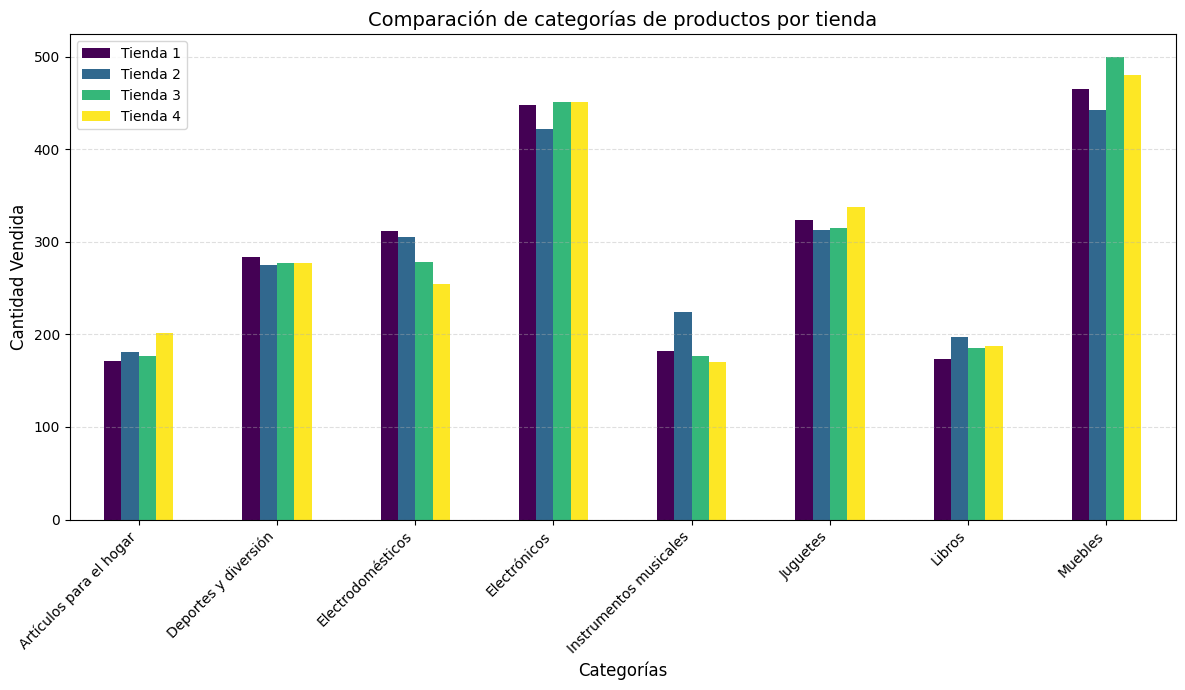

In [137]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Conteo de categorías por tienda
categorias_tienda1 = tienda['Categoría del Producto'].value_counts()
categorias_tienda2 = tienda2['Categoría del Producto'].value_counts()
categorias_tienda3 = tienda3['Categoría del Producto'].value_counts()
categorias_tienda4 = tienda4['Categoría del Producto'].value_counts()

# Crear DataFrame comparativo
categorias_df = pd.DataFrame({
    'Tienda 1': categorias_tienda1,
    'Tienda 2': categorias_tienda2,
    'Tienda 3': categorias_tienda3,
    'Tienda 4': categorias_tienda4
}).fillna(0)

# Configuración del gráfico
plt.figure(figsize=(12,7))

# Colores profesionales
colores = plt.cm.viridis(
    np.linspace(0, 1, len(categorias_df.columns))
)

# Gráfico comparativo
categorias_df.plot(
    kind='bar',
    figsize=(12,7),
    color=colores
)

# Título y etiquetas
plt.title(
    "Comparación de categorías de productos por tienda",
    fontsize=14
)

plt.xlabel("Categorías", fontsize=12)
plt.ylabel("Cantidad Vendida", fontsize=12)

plt.xticks(rotation=45, ha='right')

# Cuadrícula
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Ajuste visual
plt.tight_layout()

# Mostrar gráfico
plt.show()

### Insight

La categoría Muebles destaca como una de las más demandadas en varias tiendas, especialmente en la Tienda 3.

## 4. Satisfacción del cliente

Se analiza la calificación promedio de cada tienda como indicador de experiencia y satisfacción del cliente.

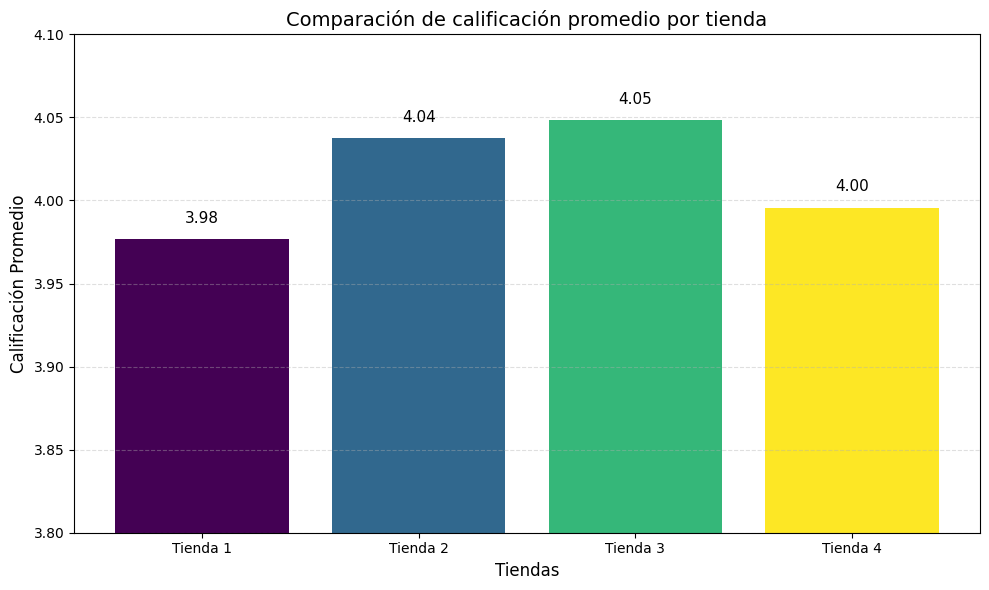

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# Calificación promedio de cada tienda
calificaciones = {
    'Tienda 1': tienda['Calificación'].mean(),
    'Tienda 2': tienda2['Calificación'].mean(),
    'Tienda 3': tienda3['Calificación'].mean(),
    'Tienda 4': tienda4['Calificación'].mean()
}

# Colores profesionales
colores = plt.cm.viridis(
    np.linspace(0, 1, len(calificaciones))
)

# Configuración del gráfico
plt.figure(figsize=(10,6))

# Gráfico de barras
bars = plt.bar(
    calificaciones.keys(),
    calificaciones.values(),
    color=colores
)

# Mostrar valores encima de cada barra
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + 0.01,
        f'{altura:.2f}',
        ha='center',
        fontsize=11
    )

# Título y etiquetas
plt.title(
    "Comparación de calificación promedio por tienda",
    fontsize=14
)

plt.xlabel("Tiendas", fontsize=12)
plt.ylabel("Calificación Promedio", fontsize=12)

# Ajustar eje Y para notar diferencias
plt.ylim(3.8, 4.1)

# Cuadrícula
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Ajuste visual
plt.tight_layout()

# Mostrar gráfico
plt.show()

### Insight

La Tienda 3 obtuvo la mejor calificación promedio, lo que sugiere una mejor percepción por parte de los clientes.

## 5. Productos más y menos vendidos

Se identifican productos de alta y baja rotación para detectar oportunidades de optimización comercial e inventario.

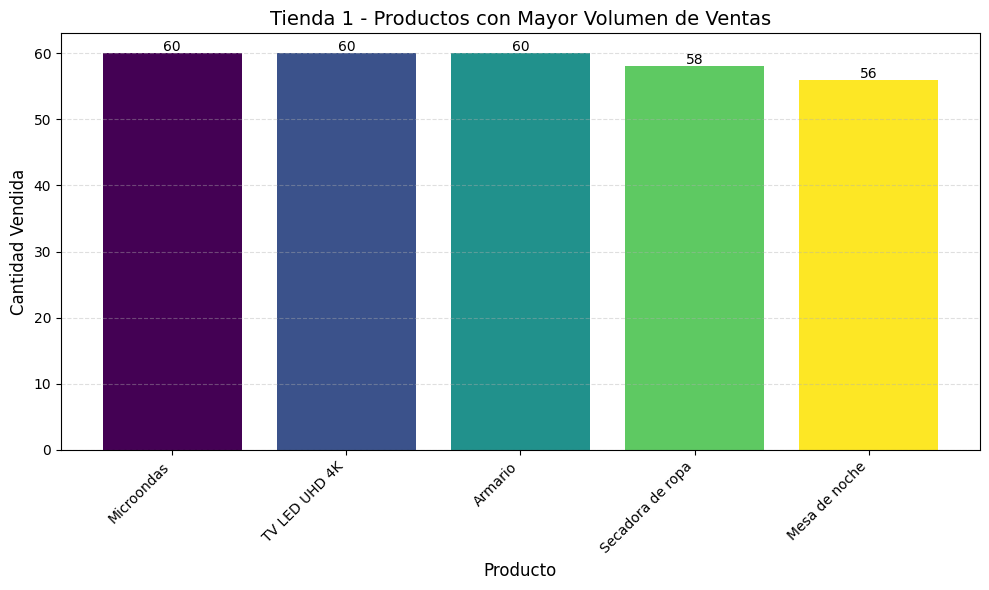

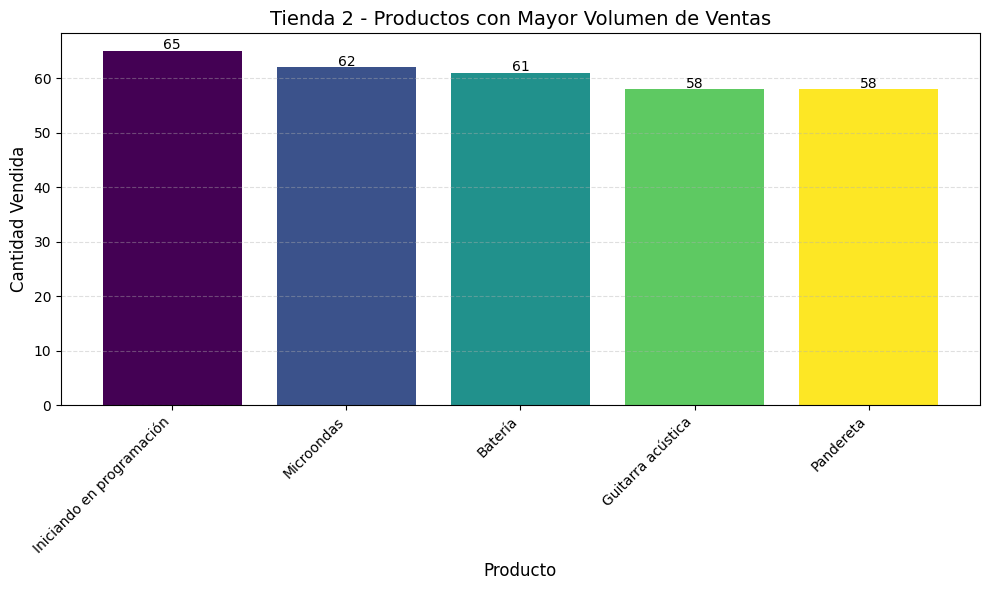

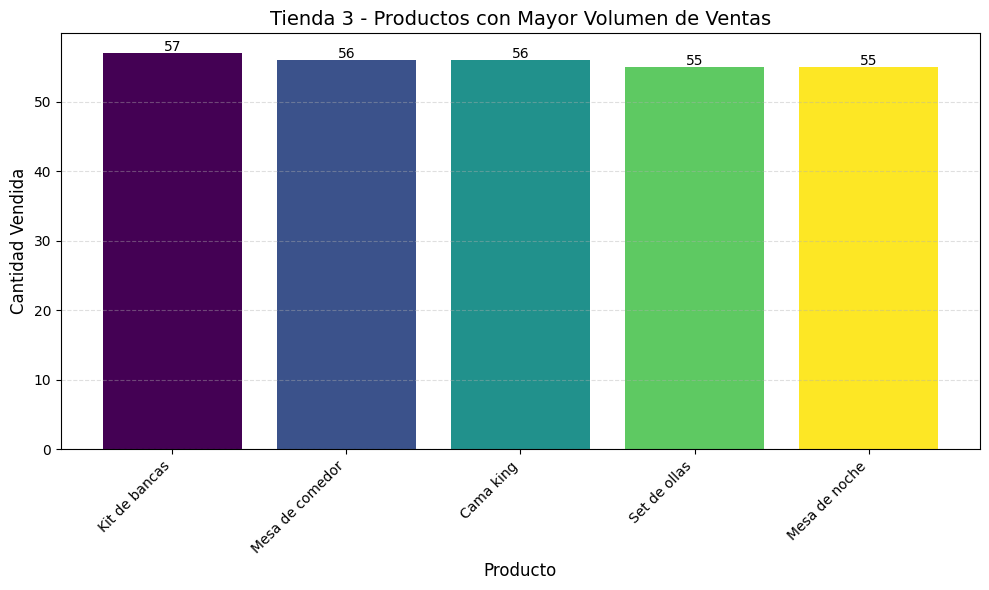

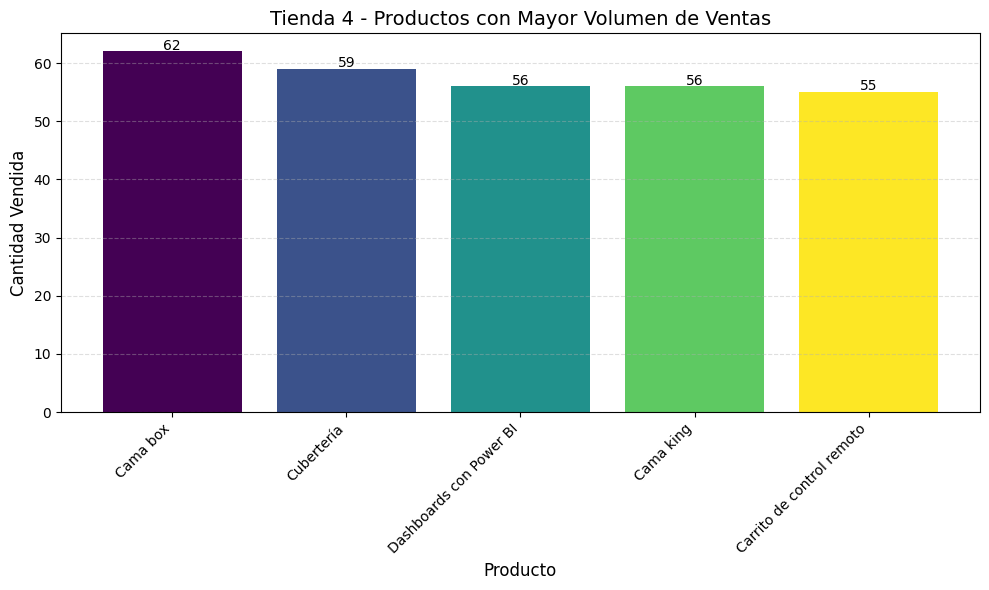

In [139]:
import matplotlib.pyplot as plt
import numpy as np

# Función para graficar los top productos por tienda
def graficar_top_ventas(ventas, nombre_tienda):

    # Top 5 productos
    top_productos = ventas.head(5)

    # Colores variados
    colores = plt.cm.viridis(
        np.linspace(0, 1, len(top_productos))
    )

    # Configuración del gráfico
    plt.figure(figsize=(10,6))

    # Crear barras
    barras = plt.bar(
        top_productos.index,
        top_productos.values,
        color=colores
    )

    # Mostrar valores encima de las barras
    for barra in barras:
        altura = barra.get_height()

        plt.text(
            barra.get_x() + barra.get_width()/2,
            altura + 0.3,
            f'{int(altura)}',
            ha='center',
            fontsize=10
        )

    # Título y etiquetas
    plt.title(
        f'{nombre_tienda} - Productos con Mayor Volumen de Ventas',
        fontsize=14
    )

    plt.ylabel('Cantidad Vendida', fontsize=12)
    plt.xlabel('Producto', fontsize=12)

    plt.xticks(rotation=45, ha='right')

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

# Graficar para cada tienda
graficar_top_ventas(ventas_prod_t1, "Tienda 1")
graficar_top_ventas(ventas_prod_t2, "Tienda 2")
graficar_top_ventas(ventas_prod_t3, "Tienda 3")
graficar_top_ventas(ventas_prod_t4, "Tienda 4")

### Insight

Los productos con mayor volumen de ventas varían entre tiendas, lo que refleja diferentes patrones de consumo y preferencias comerciales según cada establecimiento.

## 6. Costos de envío

Se calcula el costo promedio de envío para comparar la eficiencia logística de cada tienda.

In [140]:
# Calcular el costo de envío promedio por tienda
envio_prom_t1 = tienda["Costo de envío"].mean()
envio_prom_t2 = tienda2["Costo de envío"].mean()
envio_prom_t3 = tienda3["Costo de envío"].mean()
envio_prom_t4 = tienda4["Costo de envío"].mean()

# Mostrar resultados
print(f"Costo de envío promedio Tienda 1: {envio_prom_t1:.2f}")
print(f"Costo de envío promedio Tienda 2: {envio_prom_t2:.2f}")
print(f"Costo de envío promedio Tienda 3: {envio_prom_t3:.2f}")
print(f"Costo de envío promedio Tienda 4: {envio_prom_t4:.2f}")


Costo de envío promedio Tienda 1: 26018.61
Costo de envío promedio Tienda 2: 25216.24
Costo de envío promedio Tienda 3: 24805.68
Costo de envío promedio Tienda 4: 23459.46


### Insight

La Tienda 4 presenta el menor costo de envío promedio, representando una ventaja competitiva a nivel logístico.

## 7. Visualización de resultados

Las visualizaciones permiten comparar indicadores clave y facilitar la interpretación de resultados comerciales.

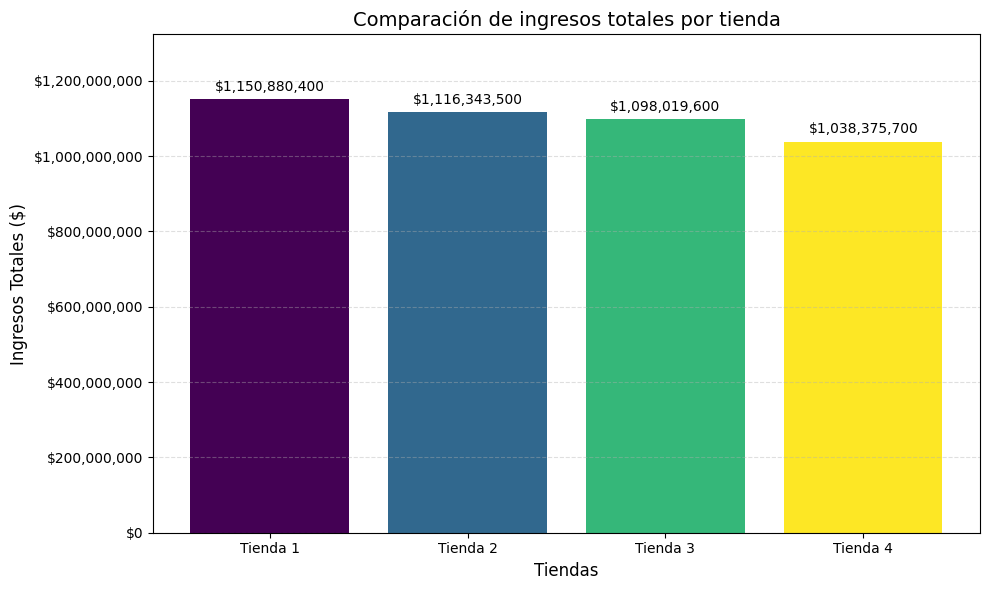

In [141]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

# Diccionario con ingresos por tienda
ingresos = {
    "Tienda 1": tienda["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum()
}

# Colores
colores = plt.cm.viridis(
    np.linspace(0, 1, len(ingresos))
)

# Configuración
fig, ax = plt.subplots(figsize=(10,6))

# Barras
barras = ax.bar(
    ingresos.keys(),
    ingresos.values(),
    color=colores
)

# Valor máximo
max_ingreso = max(ingresos.values())

# Espacio superior
ax.set_ylim(0, max_ingreso * 1.15)

# Valores encima de barras
for barra in barras:

    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + (max_ingreso * 0.02),
        f'${altura:,.0f}',
        ha='center',
        fontsize=10
    )

# Título y etiquetas
ax.set_title(
    "Comparación de ingresos totales por tienda",
    fontsize=14
)

ax.set_ylabel(
    "Ingresos Totales ($)",
    fontsize=12
)

ax.set_xlabel(
    "Tiendas",
    fontsize=12
)

# Formato moneda
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

# Cuadrícula
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Ajuste visual
plt.tight_layout()

# Mostrar
plt.show()

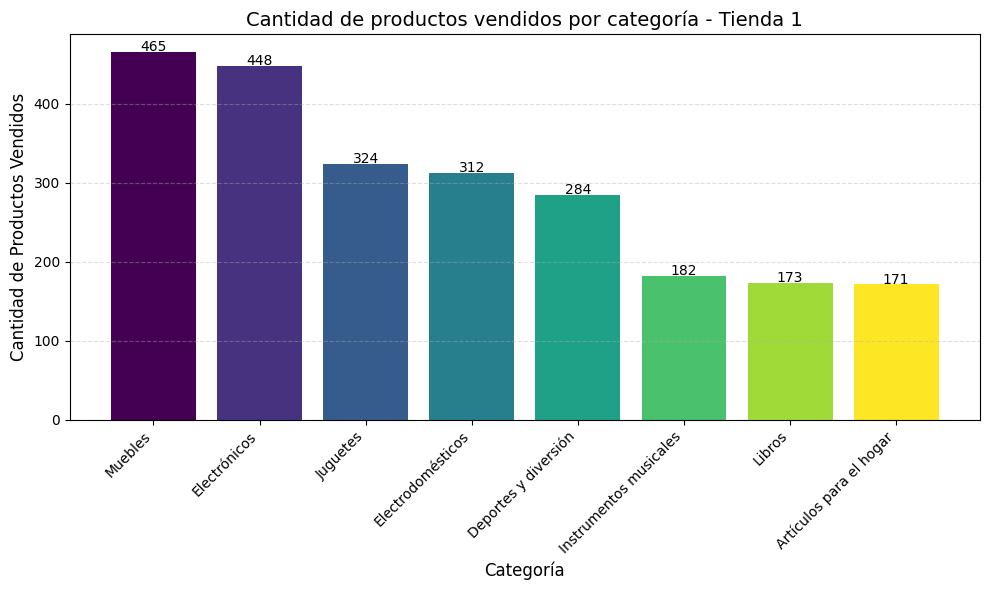

In [142]:
import matplotlib.pyplot as plt
import numpy as np

# Distribución de categorías en Tienda 1
cat_tienda1 = tienda['Categoría del Producto'].value_counts()

# Colores variados
colores = plt.cm.viridis(
    np.linspace(0, 1, len(cat_tienda1))
)

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(10,6))

# Crear barras
barras = ax.bar(
    cat_tienda1.index,
    cat_tienda1.values,
    color=colores
)

# Mostrar valores encima de las barras
for barra in barras:

    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + 1,
        f'{int(altura)}',
        ha='center',
        fontsize=10
    )

# Título y etiquetas
ax.set_title(
    "Cantidad de productos vendidos por categoría - Tienda 1",
    fontsize=14
)

ax.set_xlabel(
    "Categoría",
    fontsize=12
)

ax.set_ylabel(
    "Cantidad de Productos Vendidos",
    fontsize=12
)

# Rotación etiquetas
plt.xticks(rotation=45, ha='right')

# Cuadrícula
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Ajuste visual
plt.tight_layout()

# Mostrar gráfico
plt.show()

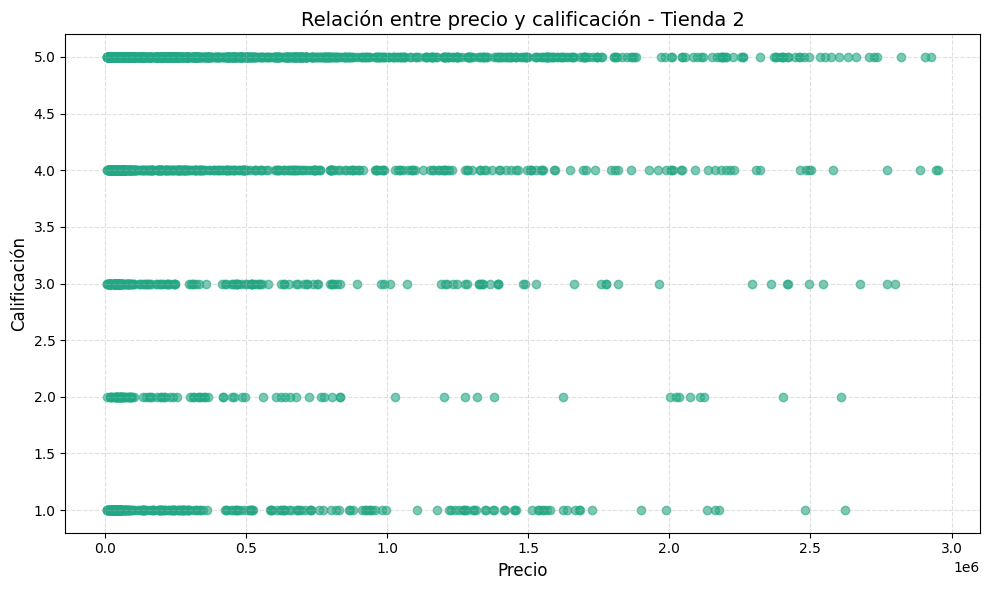

In [143]:
# Gráfico de dispersión de Precio vs Calificación

plt.figure(figsize=(10,6))

plt.scatter(
    tienda2['Precio'],
    tienda2['Calificación'],
    alpha=0.6,
    color=plt.cm.viridis(0.6)
)

plt.title(
    "Relación entre precio y calificación - Tienda 2",
    fontsize=14
)

plt.xlabel("Precio", fontsize=12)
plt.ylabel("Calificación", fontsize=12)

plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

## Principales Insights

- La Tienda 1 lidera en facturación total.
- La Tienda 3 presenta la mayor satisfacción del cliente.
- La Tienda 4 posee el menor costo de envío promedio.
- La categoría Muebles presenta alta demanda comercial.
- Existen diferencias importantes en el comportamiento de ventas entre tiendas.

# Informe Final de Análisis de Tiendas

## Introducción

Este análisis compara el desempeño de cuatro tiendas de Alura Store LATAM mediante indicadores de facturación, categorías más vendidas, satisfacción del cliente, productos con mayor y menor rotación, y costos de envío.

El objetivo es recomendar en qué tienda debería enfocarse el Sr. Juan para tomar una decisión comercial basada en datos.

## Principales hallazgos

### Facturación

La Tienda 1 obtuvo el mayor ingreso total, con 1,150,880,400. Esto la posiciona como la tienda con mejor desempeño en ventas generales.

### Categorías más vendidas

La categoría Muebles destaca como una de las más vendidas en las tiendas, especialmente en la Tienda 3. Esto evidencia una alta demanda en esta categoría.

### Calificación promedio

La Tienda 3 obtuvo la mejor calificación promedio, con 4.05 sobre 5, lo que indica una mejor percepción de los clientes.

### Productos más y menos vendidos

Cada tienda presenta productos líderes distintos. Esto permite identificar oportunidades para mejorar inventario, promociones y estrategias comerciales específicas.

### Costo de envío

La Tienda 4 tiene el menor costo de envío promedio, con 23,459.46, lo que representa una ventaja logística frente a las demás tiendas.

## Recomendación final

* Se recomienda priorizar la **Tienda 1** si el objetivo principal es maximizar ingresos, ya que presenta la mayor facturación total.

* Sin embargo, si la decisión busca equilibrar satisfacción del cliente y eficiencia operativa, la **Tienda 3** también representa una alternativa atractiva por su mejor calificación promedio y buen desempeño comercial.

* En conclusión, la recomendación principal es trabajar con la **Tienda 1** por su liderazgo en ingresos, pero considerar a la **Tienda 3** como segunda opción estratégica por su alta satisfacción del cliente.